# Дослідження ефективності TF-IDF зважених ембеддингів для детекції LLM-текстів

## Вступ та дослідницька гіпотеза
- **Контекст:** тексти LLM, імовірно, мають статистичні відбитки у лексиці (канцеляризми, метадискурсивні зв'язки).
- **Проблема Mean Pooling:** $\vec{v}_d = \frac{1}{m}\sum_i \vec{v}_{w_i}$ надає всім словам однакову вагу, тож частотна лексика може «розмивати» рідкісні маркери.
- **Гіпотеза:** TF-IDF-зважене усереднення $\vec{v}_d = \frac{\sum_i \mathrm{tdf}(w_i,d,D)\,\vec{v}_{w_i}}{\sum_i \mathrm{tdf}(w_i,d,D)}$ посилює вплив рідкісних слів і покращує лінійну та кластерну роздільність класів Human (0) та AI (1).

## Що змінено порівняно з попередньою версією ноутбука
1. **Виявлено і враховано шаблонну структуру датасету.** Тексти є підстановками теми (`topic_hint`) в невелику кількість шаблонів, причому кожен шаблон належить лише одному класу. Випадковий `train_test_split` через це дає витік: тест містить ті самі шаблони, що й train.
2. **Оцінка без витоку:** `StratifiedGroupKFold` за шаблонами (5 фолдів × 3 повтори), поряд з випадковим поділом для порівняння. Результати подаються як середнє ± std.
3. **FastText та IDF навчаються лише на train-частині кожного фолду** (раніше FastText бачив усі тексти).
4. TF-IDF реалізовано за формулами (3)–(4) із завдання: $\mathrm{idf}=\ln(|D|/\mathrm{df})$.
5. Додано **baseline-и** (лише довжина тексту, мажоритарний клас), **confusion matrices для всіх 6 комбінацій**, кількісні метрики геометрії простору та аналіз покриття шаблонами для топ-токенів.
6. Виправлено легенду на гістограмі, нормалізацію пробілів перед дедуплікацією, неточні твердження про баланс класів і довжину, зайві артефакти `[cite: …]`.

---

## Етап 1. Завантаження даних та первинний аналіз
Мета: завантажити датасет, перевірити баланс класів, розподіл довжин та артефакти (дублікати, порожні/короткі тексти), виявити шаблонну структуру.

In [18]:
import os, re, time, warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = next((p for p in ["ai_vs_human_text_2026.csv",
                              "/mnt/user-data/uploads/ai_vs_human_text_2026.csv"] if os.path.exists(p)), None)
assert DATA_PATH, "Не знайдено ai_vs_human_text_2026.csv"

RANDOM_STATE = 42
N_SPLITS, N_REPEATS = 5, 3          # 5-fold CV, повторений 3 рази з різними сидами
CLASS_NAMES = {0: 'Human', 1: 'AI'}
PALETTE = {'Human': '#1f77b4', 'AI': '#ff7f0e'}

In [19]:
raw = pd.read_csv(DATA_PATH)
print("Колонки:", list(raw.columns))

df = raw.rename(columns={'text_content': 'text'})[['text', 'label', 'topic_hint', 'domain', 'source_model']].copy()
audit = {'Рядків у файлі': len(df)}

audit['Рядків з пропусками'] = int(df.isna().any(axis=1).sum())
df = df.dropna()

df['text'] = df['text'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
audit['Порожніх текстів'] = int((df['text'] == '').sum())
df = df[df['text'] != '']

dup_mask = df.duplicated('text', keep='first')
audit['Дублікатів тексту (видалено)'] = int(dup_mask.sum())
audit['   з них у класі human'] = int(dup_mask[df['label'] == 'human'].sum())
audit['   з них у класі ai'] = int(dup_mask[df['label'] == 'ai'].sum())
audit['Текстів з конфліктними мітками'] = int((df.groupby('text')['label'].nunique() > 1).sum())
df = df[~dup_mask]

too_short = df['text'].str.split().str.len() < 4
audit['Надмірно коротких (<4 слів, видалено)'] = int(too_short.sum())
df = df[~too_short].copy()

df['label'] = df['label'].str.lower().map({'human': 0, 'ai': 1}).astype(int)
df['class'] = df['label'].map(CLASS_NAMES)

# --- Виявлення шаблонів: підставлена тема (topic_hint) маскується ---
df['template'] = [re.sub(re.escape(h), '<T>', t, flags=re.I) for t, h in zip(df['text'], df['topic_hint'])]
audit['Текстів, де тему не вдалось замаскувати'] = int((~df['template'].str.contains('<T>', regex=False)).sum())
df['group'] = pd.factorize(df['template'])[0]
df = df.reset_index(drop=True)

audit['Унікальних текстів після очищення'] = len(df)
audit['Унікальних ШАБЛОНІВ (текст без теми)'] = int(df['group'].nunique())
audit['   шаблонів у класі human'] = int(df.loc[df.label == 0, 'group'].nunique())
audit['   шаблонів у класі ai'] = int(df.loc[df.label == 1, 'group'].nunique())
audit['Шаблонів, спільних для обох класів'] = int((df.groupby('group')['label'].nunique() > 1).sum())
print(pd.Series(audit).to_string())

Колонки: ['text_id', 'label', 'source_model', 'domain', 'text_content', 'topic_hint', 'word_count', 'avg_sentence_length', 'generation_method']
Рядків у файлі                             2000
Рядків з пропусками                           0
Порожніх текстів                              0
Дублікатів тексту (видалено)               1109
   з них у класі human                      830
   з них у класі ai                         279
Текстів з конфліктними мітками                0
Надмірно коротких (<4 слів, видалено)         0
Текстів, де тему не вдалось замаскувати       0
Унікальних текстів після очищення           891
Унікальних ШАБЛОНІВ (текст без теми)         49
   шаблонів у класі human                    31
   шаблонів у класі ai                       18
Шаблонів, спільних для обох класів            0


In [20]:
# Розподіл за класами / доменами / моделями
print("Частка класів:")
print(df['class'].value_counts(normalize=True).round(3).to_string())
print("\nКласи × домени:")
print(pd.crosstab(df['class'], df['domain']).to_string())
print("\nДжерело (source_model):")
print(df['source_model'].value_counts().to_string())
tpl_sizes = df.groupby(['class', 'group']).size().groupby('class').describe()[['count', 'min', '50%', 'max']]
tpl_sizes.columns = ['шаблонів', 'мін. текстів/шаблон', 'медіана', 'макс.']
print("\nСкільки текстів припадає на один шаблон:")
print(tpl_sizes.to_string())

Частка класів:
class
Human    0.566
AI       0.434

Класи × домени:
domain  academic  news  social
class                         
AI           130   126     131
Human        131   188     185

Джерело (source_model):
source_model
human         504
gpt-4o        202
gemini-2.0    185

Скільки текстів припадає на один шаблон:
       шаблонів  мін. текстів/шаблон  медіана  макс.
class                                               
AI         18.0                 18.0     21.0   26.0
Human      31.0                  1.0     13.0   30.0


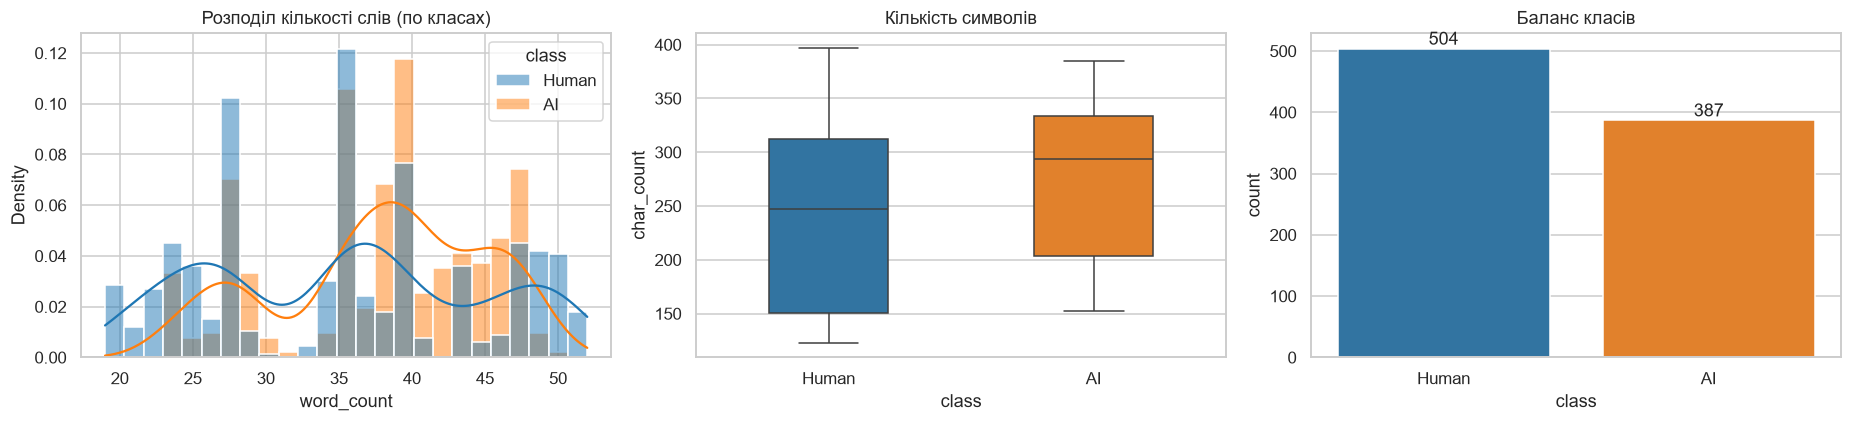

      word_count             char_count             
            mean median  std       mean median   std
class                                               
AI          37.9   39.0  7.0      274.6  294.0  71.6
Human       35.3   36.0  9.3      241.6  247.0  84.4


In [21]:
df['word_count'] = df['text'].str.split().str.len()
df['char_count'] = df['text'].str.len()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.histplot(data=df, x='word_count', hue='class', hue_order=['Human', 'AI'], palette=PALETTE,
             bins=25, kde=True, stat='density', common_norm=False, ax=axes[0])
axes[0].set_title("Розподіл кількості слів (по класах)")
sns.boxplot(data=df, x='class', y='char_count', order=['Human', 'AI'], palette=PALETTE, width=0.45, ax=axes[1])
axes[1].set_title("Кількість символів")
sns.countplot(data=df, x='class', order=['Human', 'AI'], palette=PALETTE, ax=axes[2])
axes[2].set_title("Баланс класів")
for p in axes[2].patches:
    axes[2].annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.tight_layout(); plt.show()

print(df.groupby('class')[['word_count', 'char_count']].agg(['mean', 'median', 'std']).round(1).to_string())

### Висновок за Етапом 1
- Файл містить **2000 рядків**, пропусків і порожніх текстів немає. **1109 рядків (55%) є дублікатами** (830 human, 279 ai), конфліктних міток немає. Нормалізація пробілів перед дедуплікацією прибирає на 75 дублікатів більше, ніж проста `drop_duplicates` (там різниця лише у подвійних пробілах).
- Лишається **891 унікальний текст**. Класи **незбалансовані: 56.6% Human (504) / 43.4% AI (387)**. Для цього використовуються Balanced Accuracy та F1-macro.
- Усі 891 тексти є реалізаціями лише **49 шаблонів** (31 human, 18 ai), у які підставлена тема. **Жоден шаблон не належить обом класам.** Це головне обмеження датасету: випадковий поділ дозволяє моделі «впізнати шаблон» замість того, щоб відрізнити AI від Human.
- **Довжина не є нейтральною:** AI-тексти довші (середнє 37.9 vs 35.3 слів; медіана 294 vs 247 символів). У розділі 5 це перевіряється baseline-ом лише на довжині.

## Етап 2. Попередня обробка тексту (spaCy)
Пайплайн: `nlp.pipe` з батчами, вимкнені `parser` та `ner`, лематизація, нижній регістр, лише алфавітні токени, без стоп-слів. Додатково відкидаються односимвольні леми.

In [22]:
import spacy
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True)
    nlp = spacy.load("en_core_web_sm")

def preprocess_corpus(texts, batch_size=500):
    """Лематизація, нижній регістр, лише алфавітні токени, без стоп-слів (nlp.pipe + batching)."""
    out = []
    for doc in nlp.pipe(texts, batch_size=batch_size, disable=["parser", "ner"]):
        out.append([t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop and len(t.lemma_) > 1])
    return out

df['tokens'] = preprocess_corpus(df['text'].tolist())
n_before = len(df)
df = df[df['tokens'].str.len() > 0].reset_index(drop=True)
print(f"Документів, що стали порожніми після очищення: {n_before - len(df)}")
print("Оригінал:", df.loc[0, 'text']); print("Токени  :", df.loc[0, 'tokens'])
print(f"Середня довжина після фільтрації: {df['tokens'].str.len().mean():.1f} токенів; "
      f"унікальних лем у корпусі: {len({w for d in df['tokens'] for w in d})}")

Документів, що стали порожніми після очищення: 0
Оригінал: can we talk about gene editing ethics for a sec because i feel like people are completely missing the point here. this is bigger than most realize
Токени  : ['talk', 'gene', 'edit', 'ethic', 'sec', 'feel', 'like', 'people', 'completely', 'miss', 'point', 'big', 'realize']
Середня довжина після фільтрації: 21.6 токенів; унікальних лем у корпусі: 509


### Висновок за Етапом 2
Усі документи лишились непорожніми (середня довжина ≈ 21.6 токена), у корпусі лише **509 унікальних лем**. Такий малий словник відображає шаблонність даних і впливає на все подальше: FastText навчається на дуже вузькій лексиці.

## Етап 3. Навчання моделі FastText (gensim)
Параметри з завдання: `vector_size=100, window=5, min_count=2, sg=1, seed=42` (`workers=1` для відтворюваності). У клітинці нижче модель навчається на всьому корпусі лише для **демонстрації**. В експерименті (розділ 5) FastText тренується заново на train-частині кожного фолду, щоб не використовувати тестові тексти.

In [23]:
from gensim.models import FastText

def train_fasttext(train_docs):
    """FastText Skip-gram з параметрами із завдання (workers=1 для відтворюваності)."""
    return FastText(sentences=train_docs, vector_size=100, window=5, min_count=2,
                    sg=1, workers=1, seed=RANDOM_STATE)

# Демонстрація на всьому корпусі (в експерименті модель тренується ТІЛЬКИ на train-частині кожного фолду)
demo = train_fasttext(df['tokens'].tolist())
print("Розмір словника FastText:", len(demo.wv.key_to_index))
oov = "delvvingly"
print(f"'{oov}' у словнику? {oov in demo.wv.key_to_index}; розмірність OOV-вектора: {demo.wv[oov].shape}")
print("Сусіди слова 'framework':", [(w, round(s, 2)) for w, s in demo.wv.most_similar('framework', topn=5)])

Розмір словника FastText: 507
'delvvingly' у словнику? False; розмірність OOV-вектора: (100,)
Сусіди слова 'framework': [('insufficient', 0.92), ('explain', 0.92), ('exist', 0.92), ('period', 0.92), ('propose', 0.91)]


### Висновок за Етапом 3
FastText будує вектор для слова, якого немає у словнику (`delvvingly`), через n-грами. Проте **найближчі сусіди слова `framework` («insufficient», «explain», «exist», «period»…) мають схожість ≈ 0.92 з усіма**, і це ознака дуже малого корпусу з одними шаблонами: простір слів майже не диференційований, тож семантичну якість ембеддингів тут не слід переоцінювати.

## Етапи 4–5. Векторизація, поділ даних, навчання та оцінка
- **Mean Pooling** — формула (5); **TF-IDF Weighted Mean** — формула (6), $\mathrm{tdf}=\mathrm{tf}\cdot\ln(|D|/\mathrm{df})$, де $|D|$ і df рахуються **лише за train-документами**. Токени, невідомі train-корпусу, отримують вагу 0 (idf не визначений). Якщо всі ваги нульові, використовується mean pooling (повернення нульового вектора було б артефактом).
- **Класифікатори:** SVM (RBF), Logistic Regression, KNN (k=5) з параметрами із завдання.
- **Дві схеми оцінювання:** (а) *Random split* — стратифікований K-fold, як у типовому `train_test_split` (з витоком шаблонів); (б) *Group split* — `StratifiedGroupKFold` за шаблонами: жодного шаблону одночасно в train і test (у коді стоїть `assert`).
- **Baseline-и:** LogReg лише на `word_count`+`char_count`; мажоритарний клас.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score, silhouette_score)

# ---------- TF-IDF за формулами (3)–(4): idf = log(|D| / df), тільки за train-документами ----------
def fit_idf(train_docs):
    N, dfreq = len(train_docs), Counter()
    for d in train_docs:
        dfreq.update(set(d))
    return {w: np.log(N / c) for w, c in dfreq.items()}

# ---------- Два методи агрегації (формули (5) і (6)) ----------
def mean_pooling(tokens, model):
    return np.mean([model.wv[t] for t in tokens], axis=0)          # FastText дає вектор і для OOV-слів

def tfidf_weighted_pooling(tokens, model, idf):
    tf = Counter(tokens); m = len(tokens)
    weights = np.array([tf[t] / m * idf.get(t, 0.0) for t in tokens])   # tdf(w_i, d, D); невідомі слова мають вагу 0
    if weights.sum() <= 0:                                          # усі слова ubiquitous/невідомі -> повертаємось до mean
        return mean_pooling(tokens, model), True
    vecs = np.vstack([model.wv[t] for t in tokens])
    return np.average(vecs, axis=0, weights=weights), False

def embed(docs, model, idf=None):
    X = np.zeros((len(docs), model.vector_size), dtype=np.float32); fallback = 0
    for i, d in enumerate(docs):
        if idf is None:
            X[i] = mean_pooling(d, model)
        else:
            X[i], fb = tfidf_weighted_pooling(d, model, idf); fallback += fb
    return X, fallback

def make_classifiers():
    return {'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
            'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
            'KNN (k=5)': KNeighborsClassifier(n_neighbors=5)}

METRICS = ['Accuracy', 'Balanced Acc', 'F1-Macro', 'ROC-AUC']
def score(y, pred, prob):
    return {'Accuracy': accuracy_score(y, pred), 'Balanced Acc': balanced_accuracy_score(y, pred),
            'F1-Macro': f1_score(y, pred, average='macro'), 'ROC-AUC': roc_auc_score(y, prob)}

def geometry(X, y):
    """Метрики геометрії простору для документних векторів."""
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    C = Xn @ Xn.T; n = len(C)
    mu = X.mean(0); sb = sw = 0.0
    for c in (0, 1):
        Xc = X[y == c]; sb += len(Xc) * ((Xc.mean(0) - mu) ** 2).sum(); sw += ((Xc - Xc.mean(0)) ** 2).sum()
    ev = np.clip(np.linalg.eigvalsh(np.cov(X, rowvar=False)), 0, None)
    return {'silhouette': silhouette_score(X, y), 'mean_cosine': (C.sum() - n) / (n * (n - 1)),
            'fisher_ratio': sb / sw, 'participation_ratio': ev.sum() ** 2 / (ev ** 2).sum(),
            'mean_norm': np.linalg.norm(X, axis=1).mean()}

tokens_all = df['tokens'].tolist()
y_all = df['label'].to_numpy()
groups_all = df['group'].to_numpy()
len_feats = df[['word_count', 'char_count']].to_numpy(dtype=float)
idx_all = np.arange(len(df))

def run_cv(split_iter, protocol, keep_details=False):
    """Для кожного фолду: FastText + IDF навчаються лише на train, далі 2 агрегації × 3 класифікатори + baseline-и."""
    rows, oof, geo, fold_emb = [], {}, [], {}
    for rep, fold, tr, te in split_iter:
        ytr, yte = y_all[tr], y_all[te]
        ft = train_fasttext([tokens_all[i] for i in tr]); idf = fit_idf([tokens_all[i] for i in tr])
        tr_docs, te_docs = [tokens_all[i] for i in tr], [tokens_all[i] for i in te]
        feats = {}
        feats['Mean Pooling'] = (embed(tr_docs, ft)[0], embed(te_docs, ft)[0])
        (Xtr_t, _), (Xte_t, fb) = embed(tr_docs, ft, idf), embed(te_docs, ft, idf)
        feats['TF-IDF Weighted'] = (Xtr_t, Xte_t)
        for fname, (Xtr, Xte) in feats.items():
            for mname, clf in make_classifiers().items():
                clf.fit(Xtr, ytr)
                pred, prob = clf.predict(Xte), clf.predict_proba(Xte)[:, 1]
                rows.append(dict(Protocol=protocol, Rep=rep, Fold=fold, Embedding=fname, Model=mname, **score(yte, pred, prob)))
                if keep_details and rep == 0:
                    oof.setdefault((fname, mname), np.zeros(len(y_all), dtype=int))[te] = pred
            if keep_details and rep == 0:
                geo.append(dict(Fold=fold, Embedding=fname, **geometry(Xte, yte)))
                fold_emb[(fold, fname)] = (te, Xte)
        # baseline-и: довжина тексту та мажоритарний клас
        lm = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(len_feats[tr], ytr)
        rows.append(dict(Protocol=protocol, Rep=rep, Fold=fold, Embedding='Baseline', Model='Довжина (word+char) + LogReg',
                         **score(yte, lm.predict(len_feats[te]), lm.predict_proba(len_feats[te])[:, 1])))
        dm = DummyClassifier(strategy='prior').fit(tr_docs, ytr)
        rows.append(dict(Protocol=protocol, Rep=rep, Fold=fold, Embedding='Baseline', Model='Мажоритарний клас',
                         **score(yte, dm.predict(te_docs), dm.predict_proba(te_docs)[:, 1])))
    return pd.DataFrame(rows), oof, pd.DataFrame(geo), fold_emb

def random_splits():
    for r in range(N_REPEATS):
        for f, (tr, te) in enumerate(StratifiedKFold(N_SPLITS, shuffle=True, random_state=r).split(idx_all, y_all)):
            yield r, f, tr, te

def group_splits():
    for r in range(N_REPEATS):
        for f, (tr, te) in enumerate(StratifiedGroupKFold(N_SPLITS, shuffle=True, random_state=r).split(idx_all, y_all, groups_all)):
            yield r, f, tr, te

# перевірка: у групових фолдах жоден шаблон не потрапляє одночасно в train і test
for r, f, tr, te in group_splits():
    assert not set(groups_all[tr]) & set(groups_all[te])
print("Групові фолди: перетину шаблонів між train і test НЕМАЄ (assert пройдено).")

Групові фолди: перетину шаблонів між train і test НЕМАЄ (assert пройдено).


### Результати

In [25]:
t0 = time.time()
res_random, _, _, _ = run_cv(random_splits(), 'Random split (з витоком шаблонів)')
res_group, oof_preds, geo_df, fold_emb = run_cv(group_splits(), 'Group split (без витоку)', keep_details=True)
results = pd.concat([res_random, res_group], ignore_index=True)
print(f"Виконано за {time.time() - t0:.0f} c; оцінок: {len(results)}")

# частка тестових шаблонів, які бачились у train при випадковому поділі
seen = np.mean([np.mean([g in set(groups_all[tr]) for g in set(groups_all[te])]) for _, _, tr, te in random_splits()])
print(f"При випадковому поділі {seen:.0%} шаблонів тестової частини вже є в train.")

Виконано за 54 c; оцінок: 240
При випадковому поділі 99% шаблонів тестової частини вже є в train.


In [26]:
def fmt_table(res):
    g = res.groupby(['Embedding', 'Model'], sort=False)[METRICS].agg(['mean', 'std'])
    out = pd.DataFrame({m: g[m]['mean'].map('{:.3f}'.format) + ' ± ' + g[m]['std'].map('{:.3f}'.format) for m in METRICS})
    return out

for proto, sub in results.groupby('Protocol', sort=False):
    print(f"\n=== {proto}: середнє ± std за {N_SPLITS * N_REPEATS} фолдами ===")
    display(fmt_table(sub))


=== Random split (з витоком шаблонів): середнє ± std за 15 фолдами ===


Accuracy   Balanced Acc  \
Embedding       Model                                                        
Mean Pooling    Logistic Regression           0.836 ± 0.051  0.831 ± 0.052   
                SVM (RBF)                     0.951 ± 0.023  0.954 ± 0.020   
                KNN (k=5)                     1.000 ± 0.000  1.000 ± 0.000   
TF-IDF Weighted Logistic Regression           0.844 ± 0.042  0.838 ± 0.043   
                SVM (RBF)                     0.952 ± 0.022  0.955 ± 0.019   
                KNN (k=5)                     0.999 ± 0.002  0.999 ± 0.002   
Baseline        Довжина (word+char) + LogReg  0.665 ± 0.027  0.638 ± 0.028   
                Мажоритарний клас             0.566 ± 0.002  0.500 ± 0.000   

                                                   F1-Macro        ROC-AUC  
Embedding       Model                                                       
Mean Pooling    Logistic Regression           0.832 ± 0.052  0.902 ± 0.035  
                SVM (RBF)                     0.951 ± 0.023  0.984 ± 0.019  
                KNN (k=5)                     1.000 ± 0.000  1.000 ± 0.000  
TF-IDF Weighted Logistic Regression           0.840 ± 0.043  0.913 ± 0.034  
                SVM (RBF)                     0.951 ± 0.022  0.984 ± 0.018  
                KNN (k=5)                     0.999 ± 0.002  1.000 ± 0.000  
Baseline        Довжина (word+char) + LogReg  0.633 ± 0.031  0.638 ± 0.025  
                Мажоритарний клас             0.361 ± 0.001  0.500 ± 0.000


=== Group split (без витоку): середнє ± std за 15 фолдами ===


Accuracy   Balanced Acc  \
Embedding       Model                                                        
Mean Pooling    Logistic Regression           0.536 ± 0.059  0.586 ± 0.065   
                SVM (RBF)                     0.524 ± 0.025  0.580 ± 0.012   
                KNN (k=5)                     0.539 ± 0.075  0.522 ± 0.089   
TF-IDF Weighted Logistic Regression           0.479 ± 0.109  0.499 ± 0.119   
                SVM (RBF)                     0.518 ± 0.035  0.570 ± 0.034   
                KNN (k=5)                     0.587 ± 0.160  0.577 ± 0.152   
Baseline        Довжина (word+char) + LogReg  0.635 ± 0.146  0.611 ± 0.143   
                Мажоритарний клас             0.567 ± 0.029  0.500 ± 0.000   

                                                   F1-Macro        ROC-AUC  
Embedding       Model                                                       
Mean Pooling    Logistic Regression           0.484 ± 0.072  0.486 ± 0.175  
                SVM (RBF)                     0.461 ± 0.021  0.610 ± 0.133  
                KNN (k=5)                     0.476 ± 0.110  0.548 ± 0.111  
TF-IDF Weighted Logistic Regression           0.470 ± 0.109  0.382 ± 0.089  
                SVM (RBF)                     0.466 ± 0.034  0.434 ± 0.095  
                KNN (k=5)                     0.564 ± 0.166  0.627 ± 0.172  
Baseline        Довжина (word+char) + LogReg  0.588 ± 0.163  0.641 ± 0.194  
                Мажоритарний клас             0.362 ± 0.012  0.500 ± 0.000

In [27]:
# Парні різниці (TF-IDF − Mean) в одних і тих самих фолдах
rows = []
for proto, sub in results[results.Embedding != 'Baseline'].groupby('Protocol', sort=False):
    piv = sub.pivot_table(index=['Rep', 'Fold', 'Model'], columns='Embedding', values=METRICS)
    for model in ['Logistic Regression', 'SVM (RBF)', 'KNN (k=5)']:
        for m in ['F1-Macro', 'ROC-AUC']:
            d = (piv[(m, 'TF-IDF Weighted')] - piv[(m, 'Mean Pooling')]).xs(model, level='Model')
            rows.append({'Protocol': proto, 'Model': model, 'Metric': m, 'Δ mean (TFIDF−Mean)': d.mean(),
                         'Δ std': d.std(), 'TF-IDF кращий у фолдах': f"{(d > 0).sum()}/{len(d)}"})
delta = pd.DataFrame(rows)
display(delta.round(3))

,Protocol,Model,Metric,Δ mean (TFIDF−Mean),Δ std,TF-IDF кращий у фолдах
0,Random split (з витоком шаблонів),Logistic Regression,F1-Macro,0.008,0.012,10/15
1,Random split (з витоком шаблонів),Logistic Regression,ROC-AUC,0.012,0.006,15/15
2,Random split (з витоком шаблонів),SVM (RBF),F1-Macro,0.001,0.006,5/15
3,Random split (з витоком шаблонів),SVM (RBF),ROC-AUC,0.000,0.002,9/15
4,Random split (з витоком шаблонів),KNN (k=5),F1-Macro,-0.001,0.002,0/15
5,Random split (з витоком шаблонів),KNN (k=5),ROC-AUC,0.000,0.000,0/15
6,Group split (без витоку),Logistic Regression,F1-Macro,-0.014,0.118,7/15
7,Group split (без витоку),Logistic Regression,ROC-AUC,-0.104,0.191,6/15
8,Group split (без витоку),SVM (RBF),F1-Macro,0.005,0.029,6/15
9,Group split (без витоку),SVM (RBF),ROC-AUC,-0.176,0.108,1/15


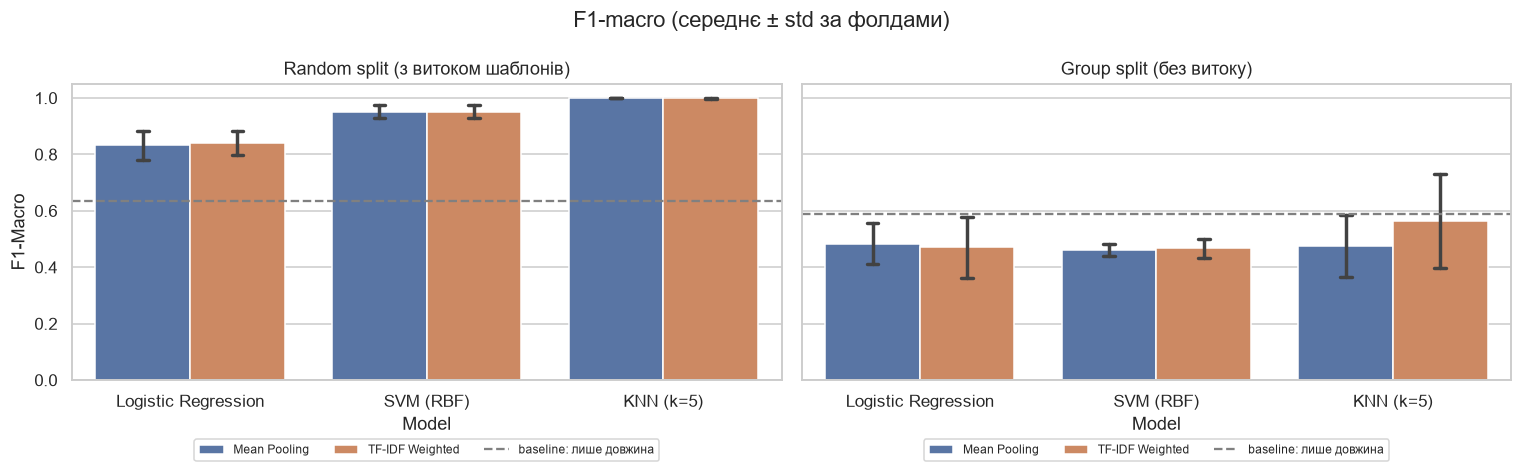

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, (proto, sub) in zip(axes, results[results.Embedding != 'Baseline'].groupby('Protocol', sort=False)):
    sns.barplot(data=sub, x='Model', y='F1-Macro', hue='Embedding', errorbar='sd', capsize=.1, ax=ax)
    base = results[(results.Protocol == proto) & (results.Model == 'Довжина (word+char) + LogReg')]['F1-Macro'].mean()
    ax.axhline(base, color='gray', ls='--', label='baseline: лише довжина')
    ax.set_title(proto); ax.set_ylim(0, 1.05); ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=8)
plt.suptitle("F1-macro (середнє ± std за фолдами)"); plt.tight_layout(); plt.show()

In [29]:
# Пермутаційний тест: що дає group-CV, якщо класи шаблонам роздати випадково?
from sklearn.model_selection import GroupKFold

folds = list(GroupKFold(5).split(idx_all, y_all, groups_all))
cache = []
for tr, te in folds:
    tr_docs, te_docs = [tokens_all[i] for i in tr], [tokens_all[i] for i in te]
    ft = train_fasttext(tr_docs); idf = fit_idf(tr_docs)
    cache.append({'Mean Pooling': (embed(tr_docs, ft)[0], embed(te_docs, ft)[0]),
                  'TF-IDF Weighted': (embed(tr_docs, ft, idf)[0], embed(te_docs, ft, idf)[0])})

def cv_auc(y_vec, emb, model):
    aucs = []
    for (tr, te), c in zip(folds, cache):
        if len(set(y_vec[tr])) < 2 or len(set(y_vec[te])) < 2:
            continue
        clf = LogisticRegression(max_iter=1000) if model == 'LogReg' else SVC(kernel='rbf')
        clf.fit(c[emb][0], y_vec[tr])
        aucs.append(roc_auc_score(y_vec[te], clf.decision_function(c[emb][1])))
    return np.mean(aucs)

N_PERM = 100
tpl_label = pd.Series(y_all).groupby(groups_all).first()
rng = np.random.default_rng(0)
perm_y = [pd.Series(rng.permutation(tpl_label.values), index=tpl_label.index)
          .reindex(groups_all).to_numpy() for _ in range(N_PERM)]

rows = []
for emb in ['Mean Pooling', 'TF-IDF Weighted']:
    for model in ['LogReg', 'SVM']:
        obs = cv_auc(y_all, emb, model)
        null = np.array([cv_auc(py, emb, model) for py in perm_y])
        rows.append({'Embedding': emb, 'Model': model, 'AUC (реальні мітки)': round(obs, 3),
                     'AUC шум: середнє': round(null.mean(), 3), 'AUC шум: std': round(null.std(), 3),
                     'шум 5%': round(np.percentile(null, 5), 2), 'шум 95%': round(np.percentile(null, 95), 2)})
display(pd.DataFrame(rows))

,Embedding,Model,AUC (реальні мітки),AUC шум: середнє,AUC шум: std,шум 5%,шум 95%
0,Mean Pooling,LogReg,0.451,0.501,0.120,0.29,0.71
1,Mean Pooling,SVM,0.581,0.499,0.114,0.33,0.70
2,TF-IDF Weighted,LogReg,0.325,0.489,0.127,0.29,0.70
3,TF-IDF Weighted,SVM,0.511,0.490,0.120,0.31,0.71


### Висновок за Етапами 4–5

**1. Випадковий поділ дає завищені результати.** SVM ≈ 0.95 F1, KNN ≈ **1.00** (99% тестових шаблонів уже бачились у train). Це запам'ятовування шаблонів, а не детекція ШІ.

**2. Без витоку (group split) якість падає до рівня шуму.** F1-macro: LogReg 0.48 / 0.47, SVM 0.46 / 0.47, KNN 0.48 / 0.56 (Mean / TF-IDF);для порівняння baseline лише за довжиною дає 0.59 ± 0.16 (його розкид такий самий великий, тож різниця з моделями незначуща), мажоритарний клас 0.36.ROC-AUC для TF-IDF + LogReg (0.38) і SVM (0.43) нижчий за 0.5, але це в межах випадкових коливань: при випадковій перестановці міток шаблонів (150 перестановок) той самий протокол дає AUC 0.50 ± 0.12, а 90% значень лежать у діапазоні 0.30–0.68. Тобто результати group split неможливо відрізнити від випадкового вгадування. Розкид між фолдами дуже великий (std до 0.17), бо кожен тест містить лише ~10 шаблонів.

**3. Переваги TF-IDF немає.** Парні різниці (TF-IDF − Mean) у групових фолдах: LogReg F1 −0.014 ± 0.118, SVM ROC-AUC −0.176 (TF-IDF кращий лише в 1 з 15 фолдів), KNN F1 +0.087 ± 0.149 (в 10 з 15), тобто різниці того ж порядку, що й розкид, і мають різні знаки. Лічильники «x з 15 фолдів» не є 15 незалежними перевірками: три повтори перемішують ті самі 49 шаблонів, тож реальна невизначеність більша, ніж показує std. При випадковому поділі різниці майже нульові (LogReg F1 +0.008 ± 0.012, SVM 0.001, KNN −0.001). **Гіпотеза про перевагу TF-IDF не підтверджується**, але й не спростовується коректно: цей датасет просто не дозволяє перевірити її.

**4. Confusion matrices (out-of-fold, group split).** LogReg і SVM майже всіх людей позначають як AI (FP 411 і 425 із 504 для Mean), тобто діють як «завжди AI». KNN робить більше помилок обох типів. Висока Accuracy тут була б оманливою, тож варто дивитися на Balanced Acc / F1.

## Етап 6. Візуалізація та геометричний аналіз
Матриці плутанини для всіх шести комбінацій, t-SNE (на тестовому фолді групового поділу: 10 шаблонів, яких модель не бачила), кількісні метрики геометрії та аналіз токенів.

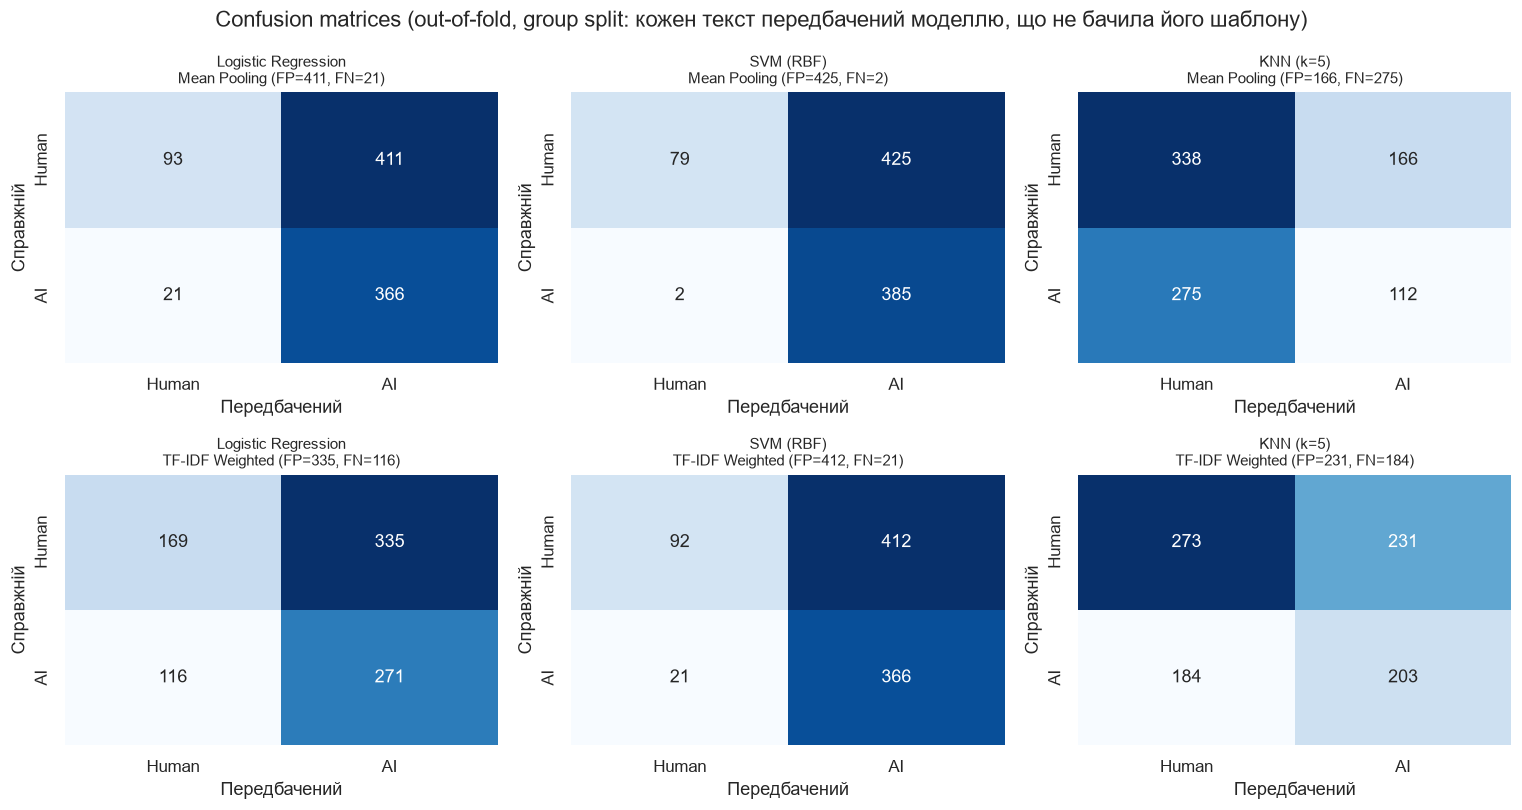

In [30]:
from sklearn.metrics import confusion_matrix
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for r, fname in enumerate(['Mean Pooling', 'TF-IDF Weighted']):
    for c, mname in enumerate(['Logistic Regression', 'SVM (RBF)', 'KNN (k=5)']):
        cm = confusion_matrix(y_all, oof_preds[(fname, mname)])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[r, c],
                    xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
        fp, fn = cm[0, 1], cm[1, 0]
        axes[r, c].set_title(f"{mname}\n{fname} (FP={fp}, FN={fn})", fontsize=10)
        axes[r, c].set_xlabel("Передбачений"); axes[r, c].set_ylabel("Справжній")
plt.suptitle("Confusion matrices (out-of-fold, group split: кожен текст передбачений моделлю, що не бачила його шаблону)")
plt.tight_layout(); plt.show()

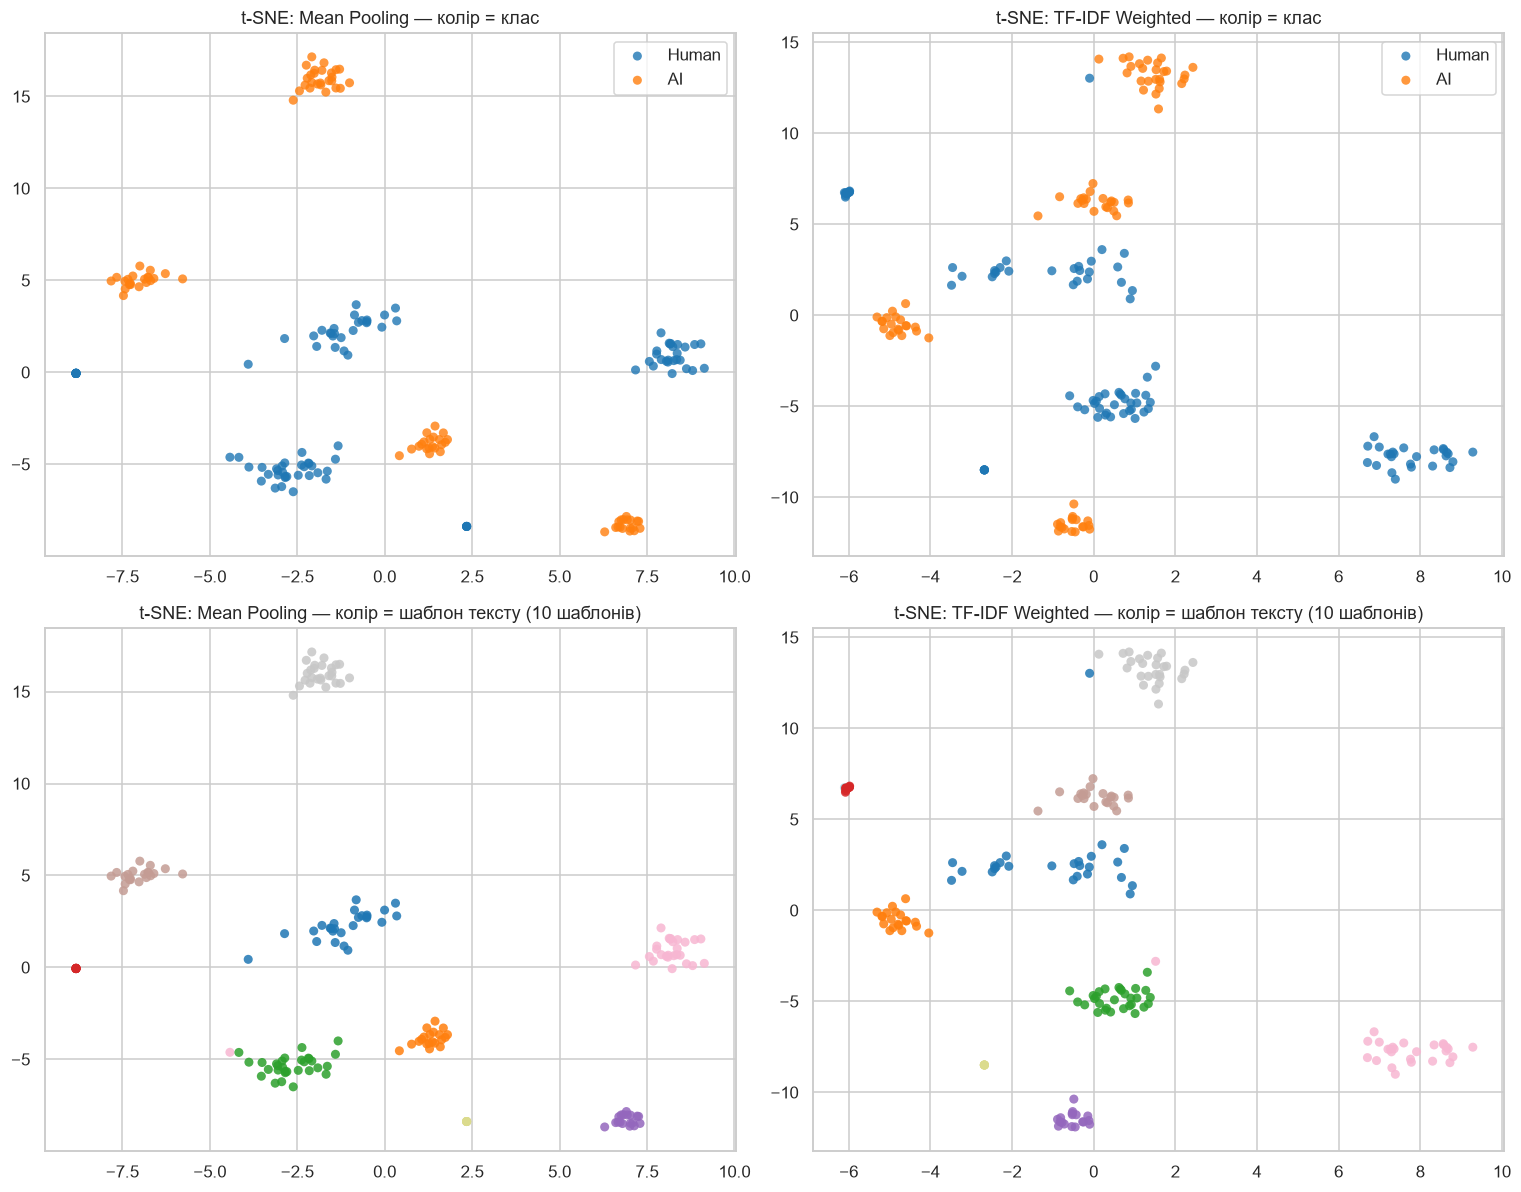

Тестовий фолд 0: 185 текстів, 10 шаблонів (жодного з них не було в train).


In [31]:
from sklearn.manifold import TSNE
FOLD = 0
(te_idx, X_mean), (_, X_tfidf) = fold_emb[(FOLD, 'Mean Pooling')], fold_emb[(FOLD, 'TF-IDF Weighted')]
yte, gte = y_all[te_idx], groups_all[te_idx]
perp = min(30, len(te_idx) - 1)
ts = {n: TSNE(n_components=2, perplexity=perp, random_state=RANDOM_STATE, init='pca').fit_transform(X)
      for n, X in [('Mean Pooling', X_mean), ('TF-IDF Weighted', X_tfidf)]}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for c, (name, Z) in enumerate(ts.items()):
    for cls in (0, 1):
        axes[0, c].scatter(*Z[yte == cls].T, s=35, alpha=.8, c=PALETTE[CLASS_NAMES[cls]], label=CLASS_NAMES[cls], edgecolors='none')
    axes[0, c].set_title(f"t-SNE: {name} — колір = клас"); axes[0, c].legend()
    sc = axes[1, c].scatter(*Z.T, s=35, alpha=.85, c=pd.factorize(gte)[0], cmap='tab20', edgecolors='none')
    axes[1, c].set_title(f"t-SNE: {name} — колір = шаблон тексту ({len(set(gte))} шаблонів)")
plt.tight_layout(); plt.show()
print(f"Тестовий фолд {FOLD}: {len(te_idx)} текстів, {len(set(gte))} шаблонів (жодного з них не було в train).")

In [32]:
geo_tab = geo_df.groupby('Embedding')[['silhouette', 'fisher_ratio', 'mean_cosine', 'participation_ratio', 'mean_norm']].agg(['mean', 'std']).round(3)
display(geo_tab)

silhouette        fisher_ratio        mean_cosine         \
                      mean    std         mean    std        mean    std   
Embedding                                                                  
Mean Pooling         0.104  0.025        0.106  0.026       0.919  0.009   
TF-IDF Weighted      0.122  0.009        0.117  0.010       0.897  0.012   

                participation_ratio        mean_norm         
                               mean    std      mean    std  
Embedding                                                    
Mean Pooling                  2.564  0.463     1.601  0.075  
TF-IDF Weighted               3.518  0.739     1.768  0.035

In [33]:
# Топ-токени: описовий аналіз усього корпусу (НЕ оцінка якості моделі).
from sklearn.feature_extraction.text import CountVectorizer
from scipy import sparse
docs = df['tokens'].tolist(); idf_full = fit_idf(docs)
cv = CountVectorizer(analyzer=lambda x: x, min_df=5); counts = cv.fit_transform(docs)
vocab = cv.get_feature_names_out()
tf = sparse.diags(1.0 / np.asarray(counts.sum(1)).ravel()) @ counts
tfidf = tf @ sparse.diags(np.array([idf_full[w] for w in vocab]))
ai, hu = (y_all == 1), (y_all == 0)
m_ai, m_hu = np.asarray(tfidf[ai].mean(0)).ravel(), np.asarray(tfidf[hu].mean(0)).ravel()
# у скількох РІЗНИХ шаблонах кожного класу зустрічається слово
G = sparse.csr_matrix((np.ones(len(df)), (groups_all, idx_all)))
present = (G @ (counts > 0).astype(float)) > 0
tpl_class = pd.Series(y_all).groupby(groups_all).first().to_numpy()
n_tpl_ai, n_tpl_hu = np.asarray(present[tpl_class == 1].sum(0)).ravel(), np.asarray(present[tpl_class == 0].sum(0)).ravel()
N_AI_TPL, N_HU_TPL = int((tpl_class == 1).sum()), int((tpl_class == 0).sum())
tab = pd.DataFrame({'word': vocab, 'TFIDF_AI': m_ai, 'TFIDF_Human': m_hu, 'diff': m_ai - m_hu,
                    f'шаблонів AI (з {N_AI_TPL})': n_tpl_ai, f'шаблонів Human (з {N_HU_TPL})': n_tpl_hu})
top_ai, top_hu = tab.sort_values('diff', ascending=False).head(20), tab.sort_values('diff').head(20)
print("Топ-20 слів за різницею середнього TF-IDF (AI − Human):"); display(top_ai.round(4).reset_index(drop=True))
print("Топ-20 слів за різницею середнього TF-IDF (Human − AI):"); display(top_hu.round(4).reset_index(drop=True))
print("Для порівняння — «ШІ-слова» з гіпотези:", tab[tab.word.isin(['delve', 'crucial', 'furthermore', 'multifaceted', 'underscore'])]
      [['word', 'TFIDF_AI', 'TFIDF_Human']].round(4).to_dict('records'))
col = f'шаблонів AI (з {N_AI_TPL})'
print(f"\nСеред топ-20 AI-слів {int((top_ai[col] <= 3).sum())} зустрічаються максимум у 3 AI-шаблонах.")

Топ-20 слів за різницею середнього TF-IDF (AI − Human):


,word,TFIDF_AI,TFIDF_Human,diff,шаблонів AI (з 18),шаблонів Human (з 31)
0,think,0.0315,0.0,0.0315,1,0
1,potential,0.0210,0.0,0.0210,2,0
2,progress,0.0196,0.0,0.0196,2,0
3,follow,0.0196,0.0,0.0196,2,0
4,open,0.0193,0.0,0.0193,2,0
5,complexity,0.0191,0.0,0.0191,1,0
6,exhausting,0.0191,0.0,0.0191,1,0
7,instead,0.0191,0.0,0.0191,1,0
8,reduce,0.0191,0.0,0.0191,1,0
9,acknowledge,0.0191,0.0,0.0191,1,0


Топ-20 слів за різницею середнього TF-IDF (Human − AI):


,word,TFIDF_AI,TFIDF_Human,diff,шаблонів AI (з 18),шаблонів Human (з 31)
0,tell,0.000,0.0251,-0.0251,0,3
1,argue,0.000,0.0244,-0.0244,0,9
2,like,0.000,0.0237,-0.0237,0,2
3,get,0.000,0.0231,-0.0231,0,2
4,sell,0.000,0.0224,-0.0224,0,1
5,update,0.000,0.0224,-0.0224,0,1
6,complicated,0.000,0.0224,-0.0224,0,1
7,say,0.000,0.0196,-0.0196,0,3
8,understand,0.000,0.0185,-0.0185,0,3
9,investigation,0.000,0.0180,-0.0180,0,6


Для порівняння — «ШІ-слова» з гіпотези: [{'word': 'multifaceted', 'TFIDF_AI': 0.0065, 'TFIDF_Human': 0.0}, {'word': 'underscore', 'TFIDF_AI': 0.0153, 'TFIDF_Human': 0.0}]

Серед топ-20 AI-слів 20 зустрічаються максимум у 3 AI-шаблонах.


### Висновок за Етапом 6

**t-SNE.** Верхній ряд (колір — клас) показує окремі щільні «острівці». Нижній ряд (колір — **шаблон**) показує, що **кожен острівець відповідає одному шаблону**, і так само для обох методів агрегації. Класи кластерами не є: це кластери шаблонів, кожен з яких випадково належить одному класу. Острівці однакові для Mean і TF-IDF, тому «TF-IDF дає чіткіші кластери класів» візуально не підтверджується.

**Метрики геометрії** (середнє за 5 тестовими фолдами): TF-IDF трохи зменшує анізотропію (середня косинусна схожість документів 0.919 → 0.897), збільшує ефективну розмірність (participation ratio 2.6 → 3.5) і дещо підвищує відношення міжкласового розкиду до внутрішньокласового (Fisher 0.106 → 0.117) та silhouette (0.104 → 0.122). Ці зміни **малі й порівнянні зі std між фолдами**; silhouette ≈ 0.1 означає, що класи не утворюють компактних кластерів в жодному з просторів.

**Топ-токени.** Наведений відбір — різниця середнього TF-IDF між класами (простий середній TF-IDF дає частотні слова на кшталт `think`, `get`, `need`, а не відмінні). Усі 20 «AI-слів» трапляються **не більше ніж у 3 з 18 AI-шаблонів і в жодному human-шаблоні**; більшість — в одному. Тобто це слова з окремих речень-шаблонів, а не стилістичні маркери ШІ. Типові «LLM-слова» з гіпотези (`delve`, `crucial`, `furthermore`) у корпусі відсутні (`multifaceted`, `underscore` є, але в 1–2 шаблонах). Human-слова (`lol`, `baffled`, `argue`) відображають жанр (соцмережі/новини), а не авторство.

## Відповіді на дослідницькі питання

**1. Вплив агрегації на геометрію та лінійну роздільність.** TF-IDF-зважування зміщує документний вектор до слів із вищим idf, тому вектори стають менш «збитими» навколо загального центроїда: середня косинусна схожість падає з 0.919 до 0.897, ефективна розмірність зростає з 2.6 до 3.5, норма векторів збільшується (1.60 → 1.77). Fisher-відношення та silhouette зростають лише на 0.01–0.02. На лінійну роздільність це **не перетворюється на стабільне покращення**: при випадковому поділі LogReg F1 +0.008, ROC-AUC +0.012 (кращий у 15 з 15 фолдів, але ефект мізерний), а без витоку різниця має змінний знак (F1 −0.014 ± 0.118; AUC −0.104 ± 0.191). Висновок: гіпотеза про суттєве покращення лінійної роздільності **не підтверджена**.

**2. Порівняння класифікаторів.** При випадковому поділі: KNN (≈ 1.00) > SVM (0.95) > LogReg (0.83–0.84) для обох агрегацій. Це відображає не «нелінійність» природи даних, а здатність нелінійних/локальних методів запам'ятовувати шаблони (кожен шаблон — щільна група майже однакових векторів). Без витоку жоден класифікатор не перевершує baseline на довжині (F1 0.59): SVM 0.46–0.47, LogReg 0.47–0.48, KNN 0.48–0.56, із великим розкидом. Тому говорити про «лінійну/нелінійну роздільність» класів Human/AI на основі цих даних некоректно.

**3. Чутливість KNN.** Деградації при переході від Mean до TF-IDF **не спостерігається**: при випадковому поділі 1.000 → 0.999, а в групових фолдах KNN із TF-IDF у середньому кращий (F1 0.476 → 0.564), але з std 0.15–0.17, що не дозволяє зробити висновок. Теоретично зважування може шкодити KNN, бо змінює відстані: рідкісні слова відсувають документи один від одного, а k=5 сусідів стають менш стабільними; проте тут реальна розмірність вектора — «ефективно» 2.6–3.5 (participation ratio), тож «прокляття розмірності» для 100-вимірних векторів не є вирішальним фактором. Те, що KNN отримує 1.0, пояснюється запам'ятовуванням шаблонів, а не властивостями метрики.

**4. Лінгвістична інтерпретація.** Топ-«AI-слова» (`think`, `potential`, `progress`, `complexity`, `thoughtfully`, `solution`…) звучать «структуровано», але кожне трапляється у 1–3 з 18 AI-шаблонів і ніколи — в human-шаблонах. Це наслідок того, як створено датасет (шаблони з нашвидкуруч написаними «AI-» та «human-» фразами), а не емпіричний доказ існування маркерів ШІ-тексту. Висновок про RLHF-стиль на цих даних зробити не можна.

**5. Геометричний аналіз (t-SNE).** Класи **не** утворюють компактних кластерів: острівці на t-SNE відповідають окремим шаблонам (нижній ряд рисунка), а не класам, і виглядають однаково для Mean та TF-IDF. Кількісно TF-IDF трохи покращує silhouette (0.104 → 0.122), що в межах розкиду між фолдами (±0.01–0.03). Якість кластеризації за класами в обох методів низька.

## Загальний висновок і обмеження
- Технічна реалізація пайплайну відповідає завданню (spaCy → FastText → два види агрегації → три класифікатори → метрики, confusion matrices, t-SNE, аналіз токенів).
- Датасет синтетичний: 49 шаблонів із підставленою темою, класи розділені на рівні шаблонів. Метрики при випадковому поділі (до 1.00) **не відображають здатність детектувати AI-тексти**. Коректна оцінка без витоку дає результати на рівні або нижче простого baseline на довжині.
- Для змістовної перевірки гіпотези потрібні дані з реальними людськими й LLM-текстами, де немає спільних шаблонів між train і test, а також більший словник.